In [3]:
from pyrokinetics import Pyro, PyroScan
import os
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt

In [4]:
# Replace with path to your Gyrokinetic Simulations
GYRO_DIR  = Path("/mnt/data/Gyrokinetic_Simulations/")

In [5]:
cases = ["M1_A1_NE","R3","R4"]

In [6]:
gs2_case_dict = {}
for case in cases:
    print(f"Case: {case}")
    json_path = Path(GYRO_DIR / Path(f"GS2/Runs/scan_beta/{case}/parameter_scan_GS2/pyroscan.json"))
    net_cdf_path = Path(GYRO_DIR / Path(f"GS2/Runs/scan_beta/{case}/parameter_scan_GS2/pyroscan.nc"))
    gs2_pyoscan = PyroScan(pyroscan_json=json_path, load_base_pyro=True)
    try:
        gs2_pyoscan.load_gk_output(netcdf_file=net_cdf_path)
        gs2_case_dict[case] = gs2_pyoscan
    except Exception as e:
        print(f"Error loading gk output for {case}: {e}")
        try:
            gs2_pyoscan.load_gk_output()
            gs2_pyoscan.gk_output.to_netcdf(net_cdf_path)
            gs2_case_dict[case] = gs2_pyoscan
        except Exception as e:
            print(f"Error saving gk output for {case}: {e}")


Case: M1_A1_NE


/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/pyrokinetics/src/pyrokinetics/normalisation.py:943: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0000'. 
  warnings.warn(


Case: R3
Case: R4


In [7]:

tglf_case_dict = {}
for case in cases:
    print(f"Case: {case}")
    json_path = Path(GYRO_DIR / Path(f"TGLF/Runs/scan_beta/{case}/parameter_scan_TGLF/pyroscan.json"))
    net_cdf_path = Path(GYRO_DIR / Path(f"TGLF/Runs/scan_beta/{case}/parameter_scan_TGLF/pyroscan.nc"))
    tglf_pyoscan = PyroScan(pyroscan_json=json_path, load_base_pyro=True)
    try:
        tglf_pyoscan.load_gk_output(netcdf_file=net_cdf_path)
        tglf_case_dict[case] = tglf_pyoscan
    except Exception as e:
        print(f"Error loading gk output for {case}: {e}")
        try:
            tglf_pyoscan.load_gk_output()
            tglf_pyoscan.gk_output.to_netcdf(net_cdf_path)
            tglf_case_dict[case] = tglf_pyoscan
        except Exception as e:
            print(f"Error saving gk output for {case}: {e}")


Case: M1_A1_NE


/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/pyrokinetics/src/pyrokinetics/normalisation.py:943: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0003'. 
  warnings.warn(


Case: R3
Case: R4


In [8]:

gftm_case_dict = {}
for case in cases:
    print(f"Case: {case}")
    json_path = Path(GYRO_DIR / Path(f"GFTM/Runs/scan_beta/{case}/parameter_scan_gftm/pyroscan.json"))
    net_cdf_path = Path(GYRO_DIR / Path(f"GFTM/Runs/scan_beta/{case}/parameter_scan_gftm/pyroscan.nc"))
    gftm_pyoscan = PyroScan(pyroscan_json=json_path, load_base_pyro=True)
    try:
        gftm_pyoscan.load_gk_output(netcdf_file=net_cdf_path)
        gftm_case_dict[case] = gftm_pyoscan
    except Exception as e:
        print(f"Error loading gk output for {case}: {e}")
        try:
            gftm_pyoscan.load_gk_output()
            gftm_pyoscan.gk_output.to_netcdf(net_cdf_path)
            gftm_case_dict[case] = gftm_pyoscan
        except Exception as e:
            print(f"Error saving gk output for {case}: {e}")


Case: M1_A1_NE


/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/pyrokinetics/src/pyrokinetics/normalisation.py:943: UserWarning: Reference values 'tref_electron', 'nref_electron', 'bref_B0', 'lref_minor_radius', 'lref_major_radius' are already set for 'pyroscan_base0006'. 
  warnings.warn(


Case: R3
Case: R4


In [9]:
gs2_case_dict["R4"].gk_output

<pyrokinetics.PyroScanGKOutput>
(Wraps <xarray.Dataset>) Size: 135MB
Dimensions:                (ky: 42, beta: 19, field: 3, theta: 1761, species: 2)
Coordinates:
  * field                  (field) <U4 48B 'phi' 'apar' 'bpar'
  * species                (species) <U8 64B 'electron' 'ion1'
  * ky                     (ky) float64 336B 0.01 0.03538 0.06077 ... 0.9746 1.0
  * beta                   (beta) float64 152B 0.01 0.02 0.03 ... 0.17 0.18 0.19
  * theta                  (theta) float64 14kB -34.56 -34.53 ... 34.53 34.56
Data variables:
    growth_rate            (ky, beta) float64 6kB [vref_nrl/lref_minor_radius] ...
    mode_frequency         (ky, beta) float64 6kB [vref_nrl/lref_minor_radius] ...
    eigenfunctions         (ky, beta, field, theta) complex128 67MB [] (2.242...
    growth_rate_tolerance  (ky, beta) float64 6kB [] 0.0004951 ... 1.979
    particle               (ky, beta, field, species) float64 38kB [nref_electron·rhoref_pyro²·vref_nrl/lref_minor_radius²] ...
    hea

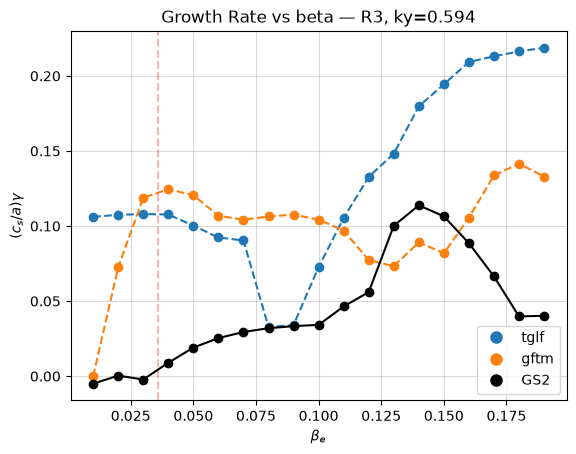

In [10]:
from matplotlib import pyplot as plt
# Plot shat scan

case = "R3"
ky = 0.6
reference_q = 0.036



tglf_case_dict[case].gk_output["growth_rate"].sel(ky =ky,method = "nearest").sel(mode =0).plot(label = "tglf",marker = "o",linestyle = "--")
gftm_case_dict[case].gk_output["growth_rate"].sel(ky =ky,method = "nearest").sel(mode =0).plot(label = "gftm",marker = "o",linestyle = "--")


gs2_growth_rate = gs2_case_dict[case].gk_output["growth_rate"].sel(ky =ky,method = "nearest")
gs2_growth_rate_tolerance = gs2_case_dict[case].gk_output["growth_rate_tolerance"].sel(ky =ky,method = "nearest")
gs2_growth_rate.plot(label = "GS2", color = "black",marker = "o")
ky_actual = float(
    gs2_case_dict[case].gk_output["growth_rate"]
    .sel(ky=ky, method="nearest")
    .ky
)

plt.axvline(x=reference_q, color='red',alpha=0.3,linestyle = "--")

plt.title(f"Growth Rate vs beta — {case}, ky={ky_actual:.3f}")
plt.xlabel(r"$\beta_e$")
plt.ylabel(r"$(c_s/a) \gamma$")
plt.grid(alpha=0.3, color='grey')
from matplotlib.lines import Line2D

handles, labels = plt.gca().get_legend_handles_labels()
dot_handles = [
    Line2D([], [], color=h.get_color(), marker="o", linestyle="none", markersize=8)
    for h in handles
]
plt.legend(dot_handles, labels)
path = f"../Plots/scan_beta/{case}"
os.makedirs(path, exist_ok=True)
plt.savefig(f"{path}/Growth Rate vs beta — {case}, ky={ky_actual:.3f}.png", dpi=300)

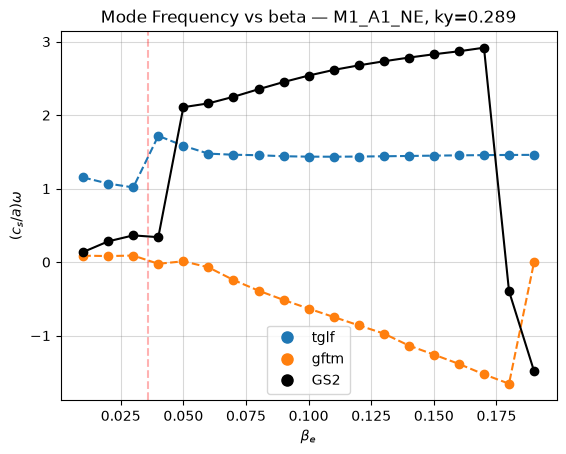

In [11]:
from matplotlib import pyplot as plt
# Plot shat scan

case = "M1_A1_NE"
ky = 0.3
reference_q = 0.036



tglf_case_dict[case].gk_output["mode_frequency"].sel(ky =ky,method = "nearest").sel(mode =0).plot(label = "tglf",marker = "o",linestyle = "--")
gftm_case_dict[case].gk_output["mode_frequency"].sel(ky =ky,method = "nearest").sel(mode =0).plot(label = "gftm",marker = "o",linestyle = "--")


gs2_mode_frequency = gs2_case_dict[case].gk_output["mode_frequency"].sel(ky =ky,method = "nearest")
# gs2_growth_rate_tolerance = gs2_case_dict[case].gk_output["growth_rate_tolerance"].sel(ky =ky,method = "nearest")
gs2_mode_frequency.plot(label = "GS2", color = "black",marker = "o")
ky_actual = float(
    gs2_case_dict[case].gk_output["mode_frequency"]
    .sel(ky=ky, method="nearest")
    .ky
)

plt.axvline(x=reference_q, color='red',alpha=0.3,linestyle = "--")

plt.title(f"Mode Frequency vs beta — {case}, ky={ky_actual:.3f}")
plt.xlabel(r"$\beta_e$")
plt.ylabel(r"$(c_s/a) \omega$")
plt.grid(alpha=0.3, color='grey')
from matplotlib.lines import Line2D

handles, labels = plt.gca().get_legend_handles_labels()
dot_handles = [
    Line2D([], [], color=h.get_color(), marker="o", linestyle="none", markersize=8)
    for h in handles
]
plt.legend(dot_handles, labels)
path = f"../Plots/scan_beta/{case}"
os.makedirs(path, exist_ok=True)
plt.savefig(f"{path}/Mode Frequency vs beta — {case}, ky={ky_actual:.3f}.png", dpi=300)

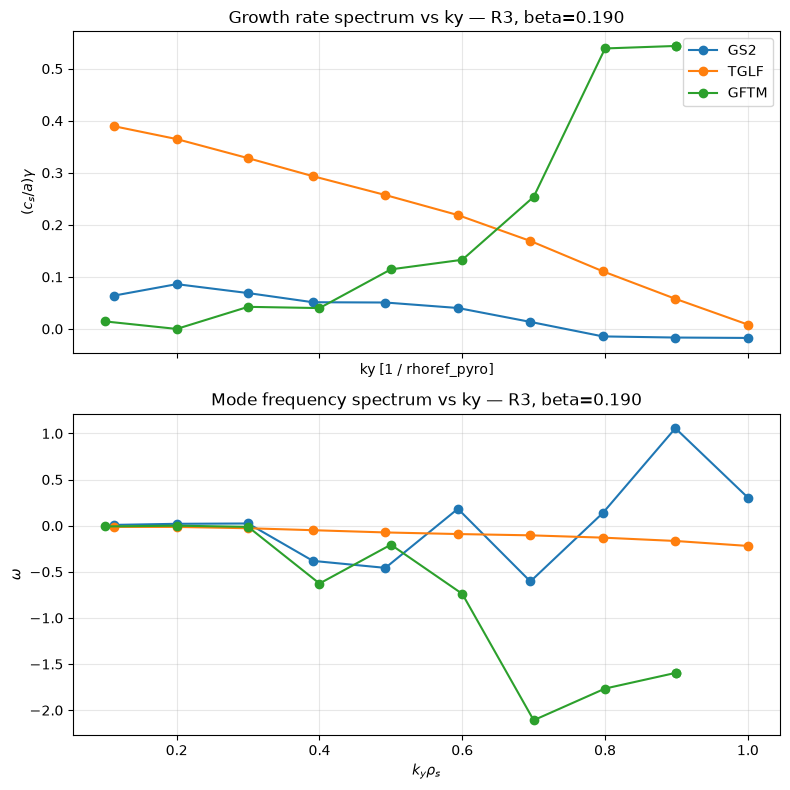

In [12]:
from matplotlib import pyplot as plt

case = "R3"
beta = 1.6
ky_values = np.linspace(0.1, 1, 10)

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

beta_used = None

for name, case_dict in [("GS2", gs2_case_dict), ("TGLF", tglf_case_dict), ("GFTM", gftm_case_dict)]:
    if name == "GS2":
        growth = case_dict[case].gk_output["growth_rate"].sel(beta=beta, method="nearest")
        freq = case_dict[case].gk_output["mode_frequency"].sel(beta=beta, method="nearest")
    else:
        growth = case_dict[case].gk_output["growth_rate"].sel(beta=beta, method="nearest").sel(mode=0)
        freq = case_dict[case].gk_output["mode_frequency"].sel(beta=beta, method="nearest").sel(mode=0)

    if beta_used is None:
        beta_used = float(growth.beta.values)

    growth.sel(ky=ky_values, method="nearest").plot.line(x="ky", ax=axes[0], marker="o", label=name)
    freq.sel(ky=ky_values, method="nearest").plot.line(x="ky", ax=axes[1], marker="o", label=name)

axes[0].set_title(f"Growth rate spectrum vs ky — {case}, beta={beta_used:.3f}")
axes[0].set_ylabel(r"$(c_s/a)\gamma$")
axes[0].grid(alpha=0.3)
axes[1].set_title(f"Mode frequency spectrum vs ky — {case}, beta={beta_used:.3f}")
axes[1].set_xlabel(r"$k_y\rho_s$")
axes[1].set_ylabel(r"$\omega$")
axes[1].grid(alpha=0.3)

axes[0].legend(loc="best")
plt.tight_layout()
path = f"../Plots/scan_beta/{case}"
os.makedirs(path, exist_ok=True)
plt.savefig(f"{path}/ky_spectra_{case}_beta_{beta_used:.3f}.png", dpi=300)
plt.show()

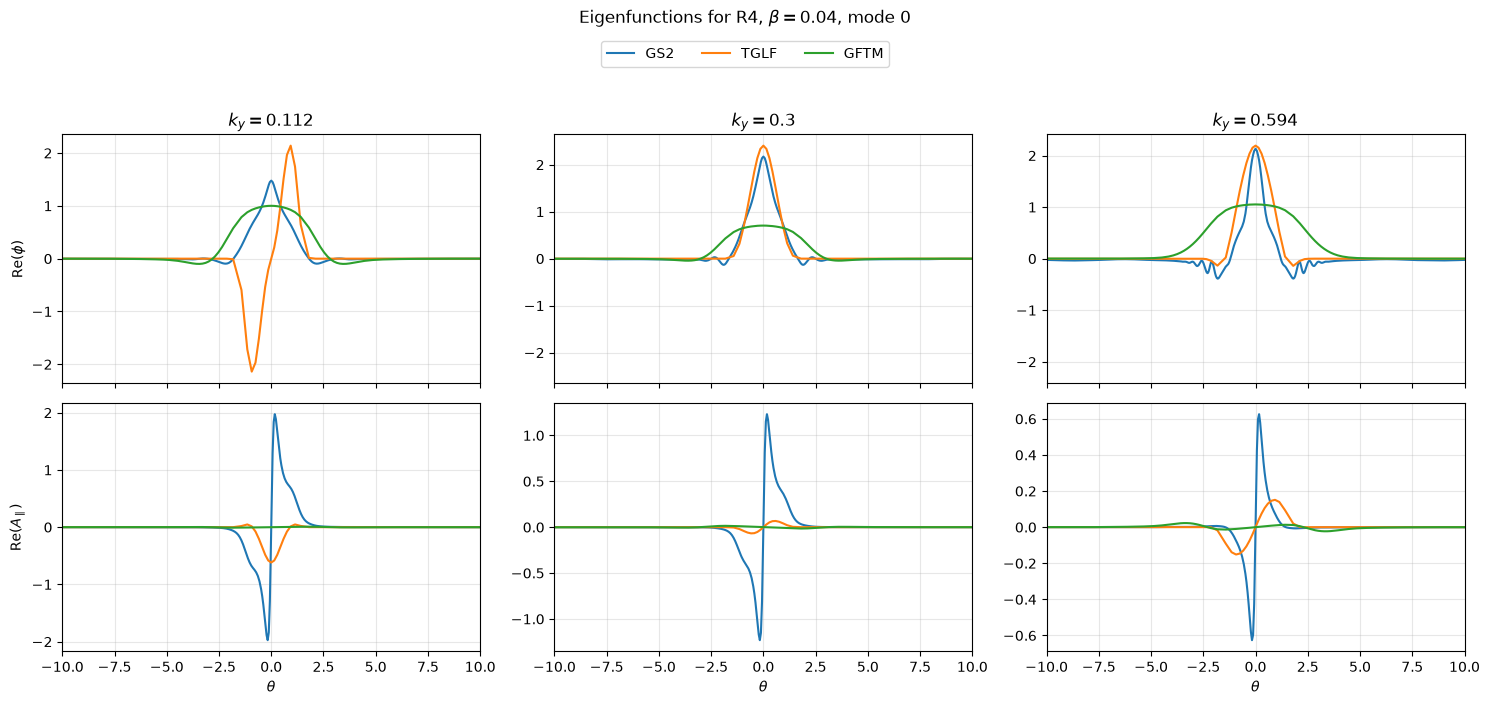

In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


case = "R4"
beta = 0.04
ky_values = [0.1, 0.3, 0.6]
mode = 0

theta_min = -10
theta_max = 10
ylim_padding = 1.1  # 10% padding

# One row for phi and one row for parallel vector potential.
field_names = ["phi", "apar"]

field_labels = {
    "phi": r"$\mathrm{Re}(\phi)$",
    "apar": r"$\mathrm{Re}(A_\parallel)$",
}

case_dictionaries = {
    "GS2": gs2_case_dict,
    "TGLF": tglf_case_dict,
    "GFTM": gftm_case_dict,
}


def select_eigenfunction(
    case_dict,
    case,
    field_name,
    beta,
    ky,
    mode=0,
):
    """Select one eigenfunction and return the coordinates actually used."""
    eig = case_dict[case].gk_output["eigenfunctions"]

    actual_beta = None
    actual_ky = None

    if "beta" in eig.dims:
        eig = eig.sel(beta=beta, method="nearest")
        actual_beta = float(eig.coords["beta"])

    if "ky" in eig.dims:
        eig = eig.sel(ky=ky, method="nearest")
        actual_ky = float(eig.coords["ky"])

    if "kx" in eig.dims:
        eig = eig.sel(kx=0.0, method="nearest")

    if "mode" in eig.dims:
        eig = eig.sel(mode=mode)

    if "field" in eig.dims:
        eig = eig.sel(field=field_name)

    eig = eig.squeeze(drop=True)

    return eig, actual_beta, actual_ky


def peak_within_theta_bounds(theta, y, theta_min, theta_max):
    """Return the max absolute value of y within the theta window."""
    mask = (theta >= theta_min) & (theta <= theta_max)

    if not np.any(mask):
        return np.max(np.abs(y))

    y_window = y[mask]

    if y_window.size == 0:
        return np.max(np.abs(y))

    return np.max(np.abs(y_window))


fig, axes = plt.subplots(
    nrows=len(field_names),
    ncols=len(ky_values),
    figsize=(5 * len(ky_values), 7),
    sharex="col",
    squeeze=False,
)

actual_betas = {}

for column, requested_ky in enumerate(ky_values):
    actual_kys = {}

    for row, field_name in enumerate(field_names):
        ax = axes[row, column]

        subplot_peak = 0.0

        for code_name, case_dict in case_dictionaries.items():
            eig, actual_beta, actual_ky = select_eigenfunction(
                case_dict=case_dict,
                case=case,
                field_name=field_name,
                beta=beta,
                ky=requested_ky,
                mode=mode,
            )

            if actual_beta is not None:
                actual_betas[code_name] = actual_beta

            if actual_ky is not None:
                actual_kys[code_name] = actual_ky

            theta = np.asarray(eig.coords["theta"].values)
            y = np.real(np.asarray(eig.values))

            ax.plot(
                theta,
                y,
                linewidth=1.5,
                label=code_name,
            )

            this_peak = peak_within_theta_bounds(theta, y, theta_min, theta_max)
            subplot_peak = max(subplot_peak, this_peak)

        ax.grid(alpha=0.3)
        ax.set_xlim(theta_min, theta_max)

        # Set y-limits based only on the visible range in theta
        if subplot_peak == 0:
            subplot_peak = 1.0
        ax.set_ylim(-ylim_padding * subplot_peak, ylim_padding * subplot_peak)

        # Only put the ky title above the phi row.
        if row == 0:
            title_ky = actual_kys.get(
                "GS2",
                next(iter(actual_kys.values()), requested_ky),
            )
            ax.set_title(rf"$k_y = {title_ky:.3g}$")

        # Only the bottom row needs x-axis labels.
        if row == len(field_names) - 1:
            ax.set_xlabel(r"$\theta$")

        # Only the first column needs field labels.
        if column == 0:
            ax.set_ylabel(field_labels[field_name])

# A single legend is sufficient because every panel contains the same codes.
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(case_dictionaries),
    bbox_to_anchor=(0.5, 0.965),
)

# Use the beta coordinate selected from GS2 where available.
actual_beta = actual_betas.get(
    "GS2",
    next(iter(actual_betas.values()), beta),
)

fig.suptitle(
    rf"Eigenfunctions for {case}, "
    rf"$\beta = {actual_beta:.5g}$, mode {mode}",
    y=1.0,
)

fig.tight_layout(rect=(0, 0, 1, 0.92))

output_directory = Path("../Plots/scan_beta") / case
output_directory.mkdir(parents=True, exist_ok=True)

output_file = (
    output_directory
    / f"eigenfunctions_phi_apar_{case}_beta_{actual_beta:.5g}.png"
)

fig.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()